## Torch Basics

В ячейках ниже вам предложено выполнить базовые операции с тензорами, модулями и параметрами, чтобы разобраться, чем является каждая сущность и какие операции можно делать с ними

In [16]:
# ⚠️ Важно!
# Из ячейки не нужно убирать или добавлять другие импорты или объединять с другими ячейками
# Нельзя менять интерфейс (входные аргументы)
# Это может сломать автотесты

import torch
import torch.nn as nn

class MyLinear(nn.Module):
    """Реализация линейного слоя (аналог nn.Linear).

    Линейный слой выполняет преобразование: output = input @ weight.T + bias (z = x * W.t + bias, #z = кол-во лин.комбинаций(нейронов) в слое)

    #П: 28х28, на каждом слое(3) есть 128,64,32 нейрона. кол-во нейронов = кол-во ЛК в слое, где для 1-его слоя: 128 ЛК с 784 параметрами(потом активация)
    для 2-го слоя: 64 ЛК с 128 параметрами - выходами из прошлого слоя(т.к на прошлом слое какие-то z < 0, то не все h активировались, но 64 ЛК будут со всеми параметрами, даже с 0)

    Args:
        in_features: размерность входного вектора
        out_features: размерность выходного вектора
        bias: использовать ли bias (по умолчанию True)
    """
    def __init__(self, in_features: int, out_features: int, bias: bool = True): #задаем свойства каждого нового экземпляра(слоя) в классе(in_features + out_features + смещение) #метод, который вызывается АВТОМАТОМ при создании экзепляра(слоя)
        super().__init__() #обращение к родительскому классу (nn.Module)
        self.in_features = in_features #т.е в создании каждого экземпляра класса (слоя) учавствует 3 параметра in_features(признаки), out_features(кол-во ЛК), смещение (=кол-во ЛК), А ТАК ЖЕ веса weight!
        self.out_features = out_features

#-----------------------------------------------------------------------------------------
        # TODO: инициализировать параметр weight размером [out_features, in_features]
        # Используйте nn.Parameter для создания обучаемого параметра
        # self.weight = nn.Parameter(...)
        # 1) Автоматически регистрируется как обучаемый параметр модуля (nn.Module) 2) Получает градиенты при backward() 3) Включается в model.parameters() и сохраняется при torch.save()



        # Создаём обучаемый параметр "weight" формы: [out_features, in_features]
        # Почему такая форма? Потому что в PyTorch так хранит веса nn.Linear
        # При вычислении: input @ weight.T → [batch, in] @ [in, out] = [batch, out] (input @ weight.T + bias)
        self.weight = nn.Parameter(
            torch.randn(out_features, in_features) * 0.01  # случайные числа из нормального распределения N(0,1)
        )

#-----------------------------------------------------------------------------------------
        # TODO: инициализировать параметр bias размером [out_features] (если bias=True) - размер будет out_features, т.к #баесов = #ЛК(out_features)
        # self.bias = nn.Parameter(...) if bias else None
        # 1) Автоматически регистрируется как обучаемый параметр модуля (nn.Module) 2) Получает градиенты при backward() 3) Включается в model.parameters() и сохраняется при torch.save()
        # Подсказка: можно использовать torch.randn для инициализации


        # Если bias=True, создаём параметр смещения; иначе — None
        if bias:
            # bias — это вектор длины out_features (по одному смещению на каждый выходной нейрон)
            self.bias = nn.Parameter(torch.zeros(out_features))

        else:
            self.bias = None  # если не нужен — просто None

#-----------------------------------------------------------------------------------------

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Выполняет линейное преобразование: y = x @ W^T + b

        Args:
            x: тензор формы [batch_size, in_features]
               batch_size — число примеров в батче (например, 32 картинки)
        Returns:
            y: тензор формы [batch_size, out_features]
        """
        # Шаг 1: умножаем вход на транспонированные веса
        output = x @ self.weight.T #тензор формы [batch_size, out_features], т.к х[batch_size, in_features] @ W.t [in_features, out_features] = [batch_size, out_features]

        # Шаг 2: добавляем смещение, если оно есть
        # PyTorch автоматически "расширяет" (broadcasting) вектор bias до формы [batch_size, out_features]
        if self.bias is not None:
            output = output + self.bias

        return output
        #после создания экземпляров класса(слоев), можем обращаться к ЛЮБЫМ методам, которые есть в классе(т.е при создании экзепляра layer_1 с параметрами (in, out, bias), где in - # входных признаков, а out - #выходов(нейронов), можем обратиться к методу forward: layer_1.forward(x))
#-----------------------------------------------------------------------------------------

def task_linear_mse_loss(                 #уже метод ВНЕ класса
    layer: MyLinear,
    x: torch.Tensor,
    y: torch.Tensor
) -> tuple[torch.Tensor, torch.Tensor]:
    """Вычислить MSE loss и градиенты по параметрам MyLinear.

    Требования:
    - layer должен быть экземпляром MyLinear
    - x - входной тензор формы [batch_size, in_features]
    - y - целевой тензор формы [batch_size, out_features]
    - Выполните forward pass через layer
    - Вычислите MSE loss: loss = mean((output - y)^2)
    - Вызовите backward() на loss
    - Верните кортеж (loss, weight_grad), где weight_grad - градиент по weight

    Returns:
        loss: torch.Tensor - скалярное значение MSE loss
        weight_grad: torch.Tensor - градиент по параметру weight формы [out_features, in_features]
    """
    # task description: MSE loss и градиенты для MyLinear
    ...
    # 1. Делаем прямой проход (forward pass): получаем предсказание модели
    output = layer(x) #т.к layer: MyLinear(экземлпяр класса), размер выхода: [batch_size, out_features]

    # 2. Считаем MSE (Mean Squared Error):
    # loss — скалярный тензор (0D)
    loss = ((output - y) ** 2).mean()

    # 3. Обнуляем старые градиенты (хорошая практика, особенно если вызываем несколько раз)
    #    У весов и смещения может уже быть .grad от предыдущего вызова
    #    Если не обнулить — новые градиенты прибавятся к старым!
    if layer.weight.grad is not None:
        layer.weight.grad.zero_()
    if layer.bias is not None and layer.bias.grad is not None:
        layer.bias.grad.zero_()

    # 4. Запускаем обратное распространение ошибки (backpropagation)
    #    PyTorch автоматически вычислит градиенты loss по всем тензорам (т.е градиенты функции потерь по каждому параметру)
    loss.backward()

    # 5. Возвращаем loss и градиент по весам
    #    layer.weight.grad имеет ту же форму, что и layer.weight: [out_features, in_features]
    return loss, layer.weight.grad

#-----------------------------------------------------------------------------------------

def task_grad_sum_of_squares(x: torch.Tensor) -> torch.Tensor:
    """Градиенты можно считать и по обычным тензорам, не только по параметрам.
    Посчитайте градиент функции f(x) = sum(x^2) по x.

    Требования:
    - x должен быть torch.Tensor с requires_grad=True
    - посчитайте f(x), вызовите backward(), верните x.grad

    Returns:
        grad: torch.Tensor той же формы, что и x
    """
    # 2. Считаем функцию f(x) = sum(x^2)
    #    x ** 2 — поэлементное возведение в квадрат
    #    torch.sum() — сумма всех элементов → скаляр
    f = torch.sum(x ** 2)

    # 3. Запускаем обратное распространение
    #    Это вычислит градиент df/dx и сохранит его в x.grad
    f.backward()

    # 4. Возвращаем градиент
    #    x.grad — тензор той же формы, что и x
    #    Математически: d/dx (sum x_i^2) = 2 * x
    return x.grad




In [17]:
def test_my_linear_basic():
    """Базовый тест для MyLinear: проверка формы выхода.""" # х[batch_size, in_features] @ W.t [in_features, out_features] = [batch_size, out_features]
    in_features = 5          # Задаём размер входа (например, 5 признаков)
    out_features = 3         # Задаём размер выхода (например, 3 нейрона, т.е 3 ЛК в каждой по 5 признаков)
    batch_size = 10          # Размер батча — 10 примеров


    layer = MyLinear(in_features, out_features)  # Создаём экземпляр слоя: 5 входов → 3 выхода (3 ЛК(выходов) в каждой по 5 признаков)
    x = torch.randn(batch_size, in_features)     # Генерируем случайный батч: [10, 5], т.е создаём 10 примеров, каждый из которых — вектор из 5 чисел(таблица 10 строк и 5 столбов)
    # т.е перед каждой фичей стоит не 1х, а 10 сразу В СТОЛБ (чтобы можно было обработать все 10 примеров параллельно для каждого признака)

    # Проверяем, что у слоя есть атрибут 'weight' (веса должны быть)
    assert hasattr(layer, 'weight'), "MyLinear должен иметь параметр weight"

    # Проверяем, что веса имеют правильную форму: [out_features, in_features] = [3, 5]
    assert layer.weight.shape == (out_features, in_features), \
        f"weight должен иметь форму ({out_features}, {in_features}), получено {layer.weight.shape}" #Обращение к атрибуту weight экземпляра

    # Если bias включён (по умолчанию True), проверяем его форму
    if layer.bias is not None:
        # bias должен быть вектором длины out_features = 3
        assert layer.bias.shape == (out_features,), \
            f"bias должен иметь форму ({out_features},), получено {layer.bias.shape}"

    # Делаем прямой проход: подаём x в слой (y = x @ W.T )
    output = layer(x)

    # Проверяем, что выход имеет правильную форму: [batch_size, out_features] = [10, 3]
    assert output.shape == (batch_size, out_features), \
        f"Выход должен иметь форму ({batch_size}, {out_features}), получено {output.shape}"


def test_my_linear_no_bias():
    """Тест MyLinear без bias."""
    in_features = 4          # Вход: 4 признака
    out_features = 2         # Выход: 2 нейрона
    batch_size = 8           # Батч из 8 примеров. т.е перед каждой фичей(4) стоит не 1х, а 8 сразу В СТОЛБ (чтобы можно было обработать все 10 примеров параллельно для каждого признака)

    # Создаём слой БЕЗ смещения (bias=False)
    layer = MyLinear(in_features, out_features, bias=False)
    x = torch.randn(batch_size, in_features)  # Случайный вход [8, 4]

    # Проверяем, что bias действительно None (т.к. мы передали bias=False)
    assert layer.bias is None, "При bias=False параметр bias должен быть None"

    # Делаем forward-проход (y = x @ W.T )
    output = layer(x)

    # Проверяем форму выхода: [8, 2]
    assert output.shape == (batch_size, out_features)


def test_my_linear_vs_torch_linear():
    """Сравнение MyLinear с nn.Linear (проверка правильности реализации)."""
    in_features = 7 # кол-во признаков в каждоый ЛК
    out_features = 4 # кол-во ЛК
    batch_size = 6 #сколько х-ов будет одновременно проверятся перед каждым признаком

    # Создаём твой слой и стандартный слой PyTorch
    my_layer = MyLinear(in_features, out_features)
    torch_layer = nn.Linear(in_features, out_features)

    # Копируем веса из torch_layer в my_layer, чтобы они были одинаковыми
    my_layer.weight.data = torch_layer.weight.data.clone()
    if my_layer.bias is not None:
        my_layer.bias.data = torch_layer.bias.data.clone()

    # Генерируем вход
    x = torch.randn(batch_size, in_features)

    # Получаем выходы из обоих слоёв
    my_output = my_layer(x)
    torch_output = torch_layer(x)

    # Проверяем, что выходы почти совпадают (с учётом ошибок округления)
    assert torch.allclose(my_output, torch_output, atol=1e-5), \
        "Выход MyLinear должен совпадать с выходом nn.Linear при одинаковых весах"


def test_my_linear_gradients():
    """Проверка работы градиентов в MyLinear."""
    in_features = 3
    out_features = 2
    batch_size = 5

    layer = MyLinear(in_features, out_features)
    # Входной тензор должен иметь requires_grad=True, чтобы можно было считать градиент по нему
    x = torch.randn(batch_size, in_features, requires_grad=True)

    output = layer(x)        # Прямой проход
    loss = output.sum()      # Искусственная функция потерь (сумма всех выходов)
    loss.backward()          # Обратное распространение

    # Проверяем, что градиенты вычислены:
    assert x.grad is not None, "Градиент по входу должен быть вычислен"
    assert layer.weight.grad is not None, "Градиент по weight должен быть вычислен"
    if layer.bias is not None:
        assert layer.bias.grad is not None, "Градиент по bias должен быть вычислен"


def test_task_linear_mse_loss():
    """Тест для task_linear_mse_loss."""
    in_features = 4
    out_features = 2
    batch_size = 5

    # Создаём слой и данные
    layer = MyLinear(in_features, out_features)
    x = torch.randn(batch_size, in_features)      # Вход: [5, 4]
    y = torch.randn(batch_size, out_features)     # Цель: [5, 2]

    # Вызываем твою функцию
    loss, weight_grad = task_linear_mse_loss(layer, x, y)

    # Проверяем типы:
    assert isinstance(loss, torch.Tensor), "loss должен быть torch.Tensor"
    assert loss.dim() == 0, "loss должен быть скаляром (0D тензор)"

    assert isinstance(weight_grad, torch.Tensor), "weight_grad должен быть torch.Tensor"
    # Проверяем форму градиента по весам: должна совпадать с формой весов
    assert weight_grad.shape == (out_features, in_features), \
        f"weight_grad должен иметь форму ({out_features}, {in_features}), получено {weight_grad.shape}"

    # Градиент не должен быть None
    assert weight_grad is not None, "weight_grad не должен быть None"

    # Проверяем, что loss действительно MSE:
    output = layer(x)
    expected_loss = ((output - y) ** 2).mean()  # Считаем MSE вручную
    # Сравниваем с тем, что вернула твоя функция
    assert torch.allclose(loss, expected_loss.detach(), atol=1e-5), \
        f"loss должен быть равен MSE: ожидалось {expected_loss.item()}, получено {loss.item()}"


def test_task_grad_sum_of_squares():
    # Создаём тензор с requires_grad=True (обязательно!)
    x = torch.randn(4, 3, requires_grad=True)
    # Вызываем твою функцию
    grad = task_grad_sum_of_squares(x)

    # Проверяем тип и форму
    assert isinstance(grad, torch.Tensor), "Ожидается torch.Tensor"
    assert grad.shape == x.shape

    # Теоретически: d/dx sum(x^2) = 2x
    # Проверяем, что градиент совпадает с 2*x
    assert torch.allclose(grad, 2 * x.detach()), "Градиент должен быть равен 2*x"


# === ЗАПУСК ТЕСТОВ ===

test_task_grad_sum_of_squares()  # Запускаем тест для градиента суммы квадратов
print("OK: task_grad_sum_of_squares")  # Если дошли сюда — тест пройден

test_my_linear_basic()           # Запускаем базовый тест
print("OK: test_my_linear_basic")

test_my_linear_no_bias()         # Тест без bias
print("OK: test_my_linear_no_bias")

test_my_linear_vs_torch_linear() # Сравнение с nn.Linear
print("OK: test_my_linear_vs_torch_linear")

test_my_linear_gradients()       # Проверка градиентов
print("OK: test_my_linear_gradients")

test_task_linear_mse_loss()      # Тест MSE и градиентов
print("OK: task_linear_mse_loss")


OK: task_grad_sum_of_squares
OK: test_my_linear_basic
OK: test_my_linear_no_bias
OK: test_my_linear_vs_torch_linear
OK: test_my_linear_gradients
OK: task_linear_mse_loss


## MLP

Теперь, когда мы осовились с базовыми операциями в торче, можно реализовать свой класс для MLP и по желанию обучить его.

Наш класс MLP должен быть гибко конфигурируемым: он принимает аргументом все скрытые размерности и функцию активации.

In [18]:
# ⚠️ Важно!
# Из ячейки не нужно убирать или добавлять другие импорты или объединять с тдругими ячейками
# Нельзя менять интерфейс (входные аргументы)
# Это может сломать автотесты

import torch
import torch.nn as nn
import torch.nn.functional as F

#Принимает список размеров скрытых слоёв: например, [784, 128, 64, 10]
#Принимает функцию активации (например, torch.relu)
#Автоматически строит последовательность линейных слоёв + активаций
#Без активации на выходе (стандарт для задач классификации)

# initialize a model
class MyMLP(nn.Module): #задаем свойства экземпляров класса(слоев)
    def __init__(
        self,
        hidden_dims: list[int],      # список размеров скрытых слоёв, например [128, 64]
        input_dim: int = 2,          # размерность входа (по умолчанию 2)
        output_dim: int = 1,         # размерность выхода (по умолчанию 1)
        activation_cls = nn.ReLU,    # класс функции активации (не экземпляр!)
    ):
        # Вызываем конструктор родительского класса nn.Module
        # Без этого PyTorch не будет считать этот объект нейросетевым модулем
        super().__init__()

        # Сохраняем входные параметры как атрибуты объекта — чтобы использовать позже
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.hidden_dims = hidden_dims

        # === 1. Входной слой ===
        # Преобразует вход из input_dim(размерность входа) в первый скрытый размер (hidden_dims[0])
        # Если hidden_dims пустой — используем output_dim как прямой выход
        first_hidden = hidden_dims[0] if hidden_dims else output_dim
        self.input_layer = nn.Linear(input_dim, first_hidden) #т.е input слой состоит из [входной размерности, 1 цифра скрытого слоя]

        # === 2. Скрытые слои ===
        # Создаём список слоёв с помощью nn.ModuleList
        # ModuleList — это как обычный Python-список, но PyTorch "видит" все модули внутри
        layers = []
        # Проходим по парам соседних размеров в hidden_dims: (h0→h1), (h1→h2), ...
        for i in range(len(hidden_dims) - 1):
            in_f = hidden_dims[i]
            out_f = hidden_dims[i + 1]
            layers.append(nn.Linear(in_f, out_f))
        # Оборачиваем список в ModuleList — теперь PyTorch знает, что это часть модели
        self.hidden_layers = nn.ModuleList(layers)

        # === 3. Выходной слой ===
        # Если есть скрытые слои — берём последний размер как вход для выходного слоя
        # Иначе — подключаем напрямую от входного слоя к выходу
        last_hidden = hidden_dims[-1] if hidden_dims else input_dim
        self.output_layer = nn.Linear(last_hidden, output_dim)

        # === 4. Активация ===
        # Создаём ЭКЗЕМПЛЯР активации из переданного КЛАССА
        # Например: activation_cls=nn.ReLU → self.activation = nn.ReLU()
        self.activation = activation_cls()

    def forward(self, x_coordinates):
        # x_coordinates ~ [batch_size, input_dim]
        # Пример: [32, 2] — 32 точки на плоскости

        # === Пропускаем через входной слой и применяем активацию ===
        # Результат: latents ~ [batch_size, first_hidden]
        latents = self.activation(self.input_layer(x_coordinates))

        # === Пропускаем через все скрытые слои ===
        # nn.ModuleList можно перебирать как обычный список
        for layer in self.hidden_layers:
            # Каждый скрытый слой: линейное преобразование + активация
            latents = self.activation(layer(latents))

        # === Пропускаем через выходной слой БЕЗ активации ===
        # В задачах регрессии/классификации (с CrossEntropy) активация на выходе не нужна
        scores = self.output_layer(latents)  # [batch_size, output_dim]
        return scores

In [19]:
# Если вы все сделали правильно, должны пройти тесты

def count_learnable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def test_count_parameters():
    model_1_hidden_layer = MyMLP(hidden_dims=[100, 100])
    assert count_learnable_parameters(model_1_hidden_layer) == 10501
    assert model_1_hidden_layer.forward(torch.rand(10, 2)).shape == torch.Size([10, 1])

    model_2_hidden_layer = MyMLP(hidden_dims=[100, 100, 100])
    assert count_learnable_parameters(model_2_hidden_layer) == 20601

    model_3_hidden_layer = MyMLP(hidden_dims=[100, 100, 100, 100])
    assert count_learnable_parameters(model_3_hidden_layer) == 30701


test_count_parameters()
print("OK")

OK


In [20]:
# Если вы все сделали правильно, должны пройти тесты

def _assert_linear_shapes(layer: nn.Linear, in_dim: int, out_dim: int):
    assert isinstance(layer, nn.Linear), f"Expected nn.Linear, got {type(layer)}"
    assert layer.in_features == in_dim, f"in_features: expected {in_dim}, got {layer.in_features}"
    assert layer.out_features == out_dim, f"out_features: expected {out_dim}, got {layer.out_features}"


def test_hidden_layers_order_and_shapes():
    input_dim = 2
    output_dim = 3

    # Case 1: single hidden layer => hidden_layers must be empty
    hidden_dims = [5]
    model = MyMLP(input_dim=input_dim, output_dim=output_dim, hidden_dims=hidden_dims, activation_cls=nn.ReLU)

    _assert_linear_shapes(model.input_layer, input_dim, hidden_dims[0])
    assert isinstance(model.hidden_layers, nn.ModuleList), "hidden_layers must be nn.ModuleList"
    assert len(model.hidden_layers) == 0, f"Expected 0 hidden layers, got {len(model.hidden_layers)}"
    _assert_linear_shapes(model.output_layer, hidden_dims[-1], output_dim)

    # Case 2: multiple hidden layers => ModuleList must connect hidden_dims sequentially
    hidden_dims = [4, 7, 11]
    model = MyMLP(input_dim=input_dim, output_dim=output_dim, hidden_dims=hidden_dims, activation_cls=nn.ReLU)

    _assert_linear_shapes(model.input_layer, input_dim, hidden_dims[0])

    assert isinstance(model.hidden_layers, nn.ModuleList), "hidden_layers must be nn.ModuleList"
    assert len(model.hidden_layers) == len(hidden_dims) - 1, (
        f"Expected {len(hidden_dims) - 1} hidden layers, got {len(model.hidden_layers)}"
    )

    expected_pairs = list(zip(hidden_dims[:-1], hidden_dims[1:]))  # (in_dim, out_dim) per hidden layer
    for i, (layer, (in_dim, out_dim)) in enumerate(zip(model.hidden_layers, expected_pairs)):
        assert isinstance(layer, nn.Linear), f"hidden_layers[{i}] must be nn.Linear, got {type(layer)}"
        _assert_linear_shapes(layer, in_dim, out_dim)

    _assert_linear_shapes(model.output_layer, hidden_dims[-1], output_dim)


# run
test_hidden_layers_order_and_shapes()
print("OK")


OK


In [21]:
from sklearn.datasets import make_moons, make_blobs

# loss function
def loss(model, Xbatch, ybatch):

    Xbatch = torch.tensor(Xbatch).float() # [ batch_size, 2 ]

    # ybatch.max() == 1, ybatch.min() == -1
    # важно: приводим к форме [ batch_size, 1 ], чтобы не было broadcasting в [batch, batch]
    ybatch = torch.tensor(ybatch).float().unsqueeze(-1) # [ batch_size, 1 ]

    # forward the model to get scores
    model_prediction = model.forward(Xbatch) # [ batch_size, 1 ]

    # svm "max-margin" loss
    losses = F.relu(1 - ybatch * model_prediction) # [ batch_size, 1 ]
    loss = losses.mean()

    # L2 regularization
    alpha = 1e-4
    reg_loss = alpha * sum((p*p).sum() for p in model.parameters())
    total_loss = loss + reg_loss

    # also get accuracy
    accuracy = ((ybatch > 0) == (model_prediction > 0)).float().mean()
    return total_loss, accuracy


# optimization

def train(model, learning_rate=0.1):

    Xbatch, ybatch = make_moons(n_samples=100, noise=0.1, random_state=1)
    ybatch = ybatch * 2 - 1 # make y be -1 or 1

    for k in range(300):

        model.zero_grad() # обнуляем градиенты с предыдущего шага

        # forward
        total_loss, acc = loss(model, Xbatch, ybatch)

        # backward
        total_loss.backward() # вычисляем новые значения градиентов

        # шаг оптимизации
        # update (sgd)
        for p in model.parameters():
            p.data = p.data - learning_rate * p.grad

        if k % 50 == 0:
            print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")


model = MyMLP(hidden_dims=[100, 100])

print("count_learnable_parameters", count_learnable_parameters(model))

train(model, learning_rate=0.1)

count_learnable_parameters 10501
step 0 loss 1.0087318420410156, accuracy 48.0%
step 50 loss 0.22041401267051697, accuracy 90.0%
step 100 loss 0.12674789130687714, accuracy 97.0%
step 150 loss 0.05235855281352997, accuracy 99.0%
step 200 loss 0.031721729785203934, accuracy 100.0%
step 250 loss 0.02399979904294014, accuracy 100.0%


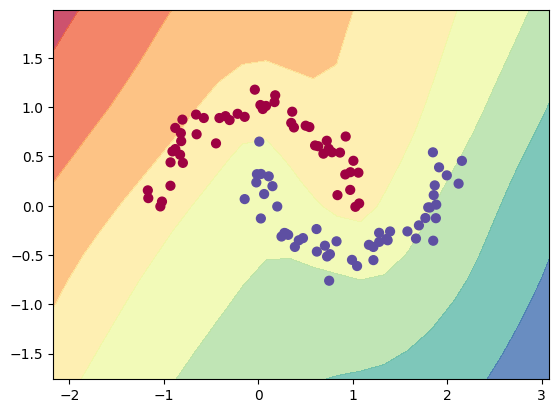

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_model_prediction(model):

    X, y = make_moons(n_samples=100, noise=0.1, random_state=1)

    h = 0.25
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))
    Xmesh = np.c_[xx.ravel(), yy.ravel()]

    if isinstance(model, nn.Module):
        with torch.no_grad():
            Xbatch = torch.tensor(Xmesh).float()

            scores = model.forward(Xbatch)
            Z = scores.numpy()

    else:
        scores = model.decision_function(Xmesh)
        Z = scores

    Z = Z.reshape(xx.shape)

    fig = plt.figure()
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

visualize_model_prediction(model)